In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import torch
import json
import pickle

sys.path.insert(0, '/workspace')

import experiments.plot_functions as pf


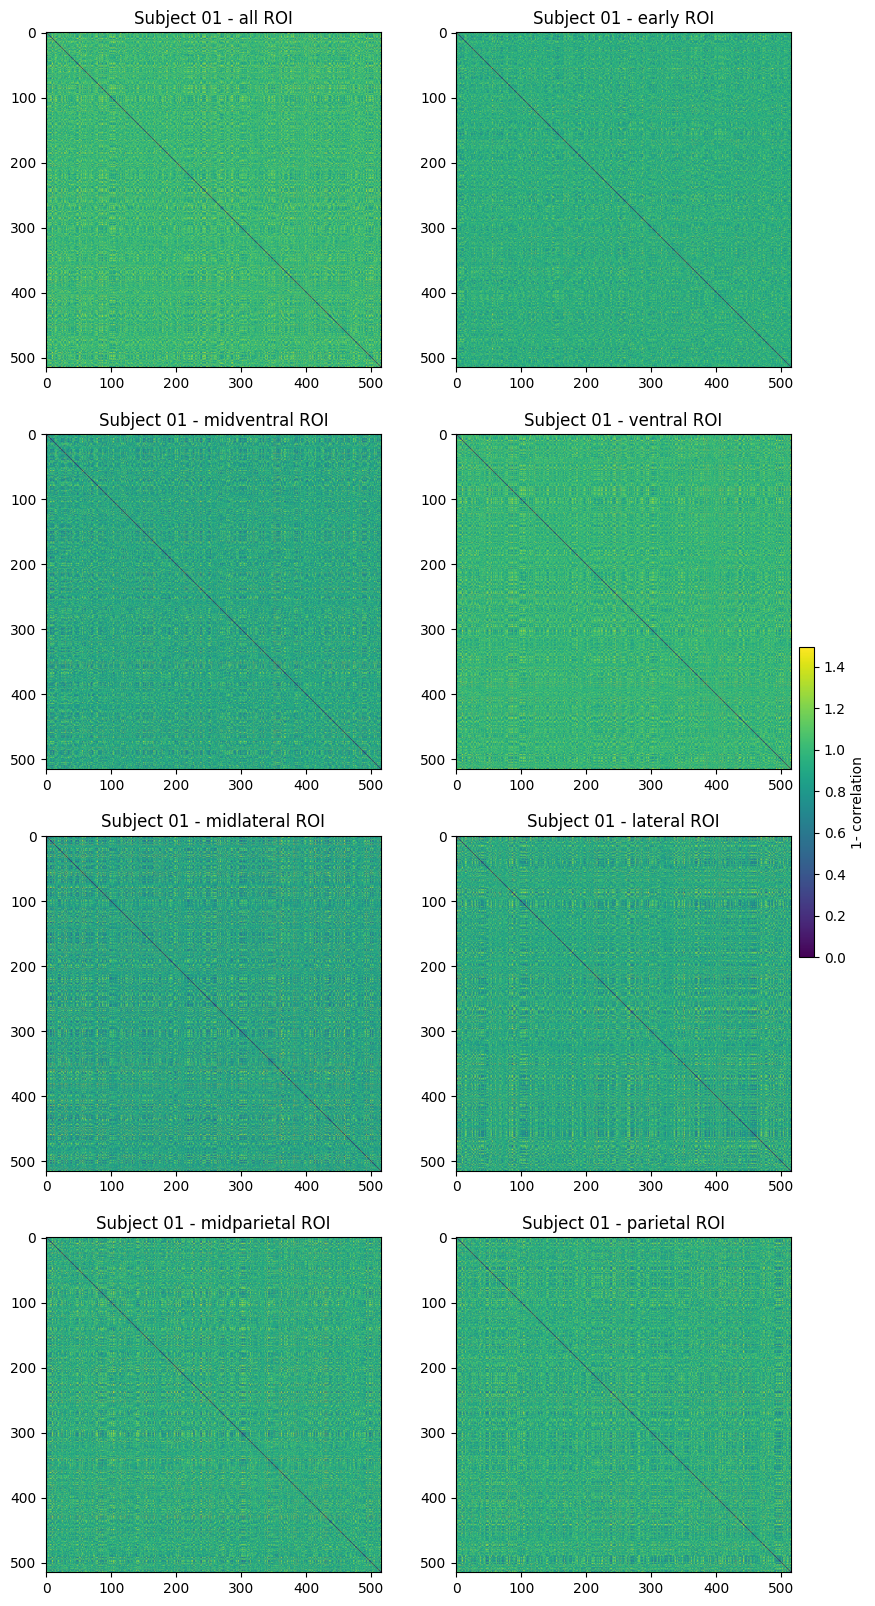

In [2]:
# visualise rdm
list_rois = [
    "all",
    "early",
    "midventral",
    "ventral",
    "midlateral",
    "lateral",
    "midparietal",
    "parietal",
]

# 2 by 4 subplots
fig, axs = plt.subplots(4, 2, figsize=(10, 20))
axs = axs.flatten()
for i, roi in enumerate(list_rois):
    brain_rdm_path = f"/workspace/data/fmri_rdms/subj01_{roi}_rdm_special515.npy"

    brain_rdm = np.load(brain_rdm_path)
    axs[i].imshow(brain_rdm, cmap='viridis')
    axs[i].set_title(f"Subject 01 - {roi} ROI")

cbar = fig.colorbar(axs[0].images[0], ax=axs, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('1- correlation')
plt.show()

In [3]:
# noise ceiling 
noise_ceiling_path = "/workspace/data/rsa/rsa_rdm_noise_ceiling_special515.json"

with open(noise_ceiling_path, 'r') as f:
    noise_ceiling = json.load(f)

# take mean noise ceiling across subjects for each roi
noise_ceiling_ave = {roi: np.mean(ceiling) for roi, ceiling in noise_ceiling.items()}
# show error bars for standard deviation across subjects
noise_ceiling_std = {roi: np.std(ceiling) for roi, ceiling in noise_ceiling.items()}

In [4]:
# plot rsa results for different model components - all layers on one graph (dot + subject lines)
list_layers = ["encoder", "latent", "decoder", "all"]
dict_models = {
    "Standard VAE": "/workspace/data/rsa/vanilla_from_ae_beta_vae_loss_standard_beta0.001_recon_loss_l2/cocoDoerig/run_0/rsa_rdm_{layer}_regression_special515.json",
    "LLM-guided VAE": "/workspace/data/rsa/beta_vae_loss_llm_alignment_beta0.001_recon_loss_l2_llm_alignment_loss_cosine_similarity_gamma0.5/cocoDoerig/run_0/rsa_rdm_{layer}_regression_special515.json",
    "Standard AE": "/workspace/data/rsa/vanilla_ae_loss_l2/cocoDoerig/run_0/rsa_rdm_{layer}_regression_special515.json",
    "LLM-guided AE": "/workspace/data/rsa/ae_loss_l2/cocoDoerig/run_0/rsa_rdm_{layer}_regression_special515.json",
}

# VAE and AE (LLM guidance vs standard)

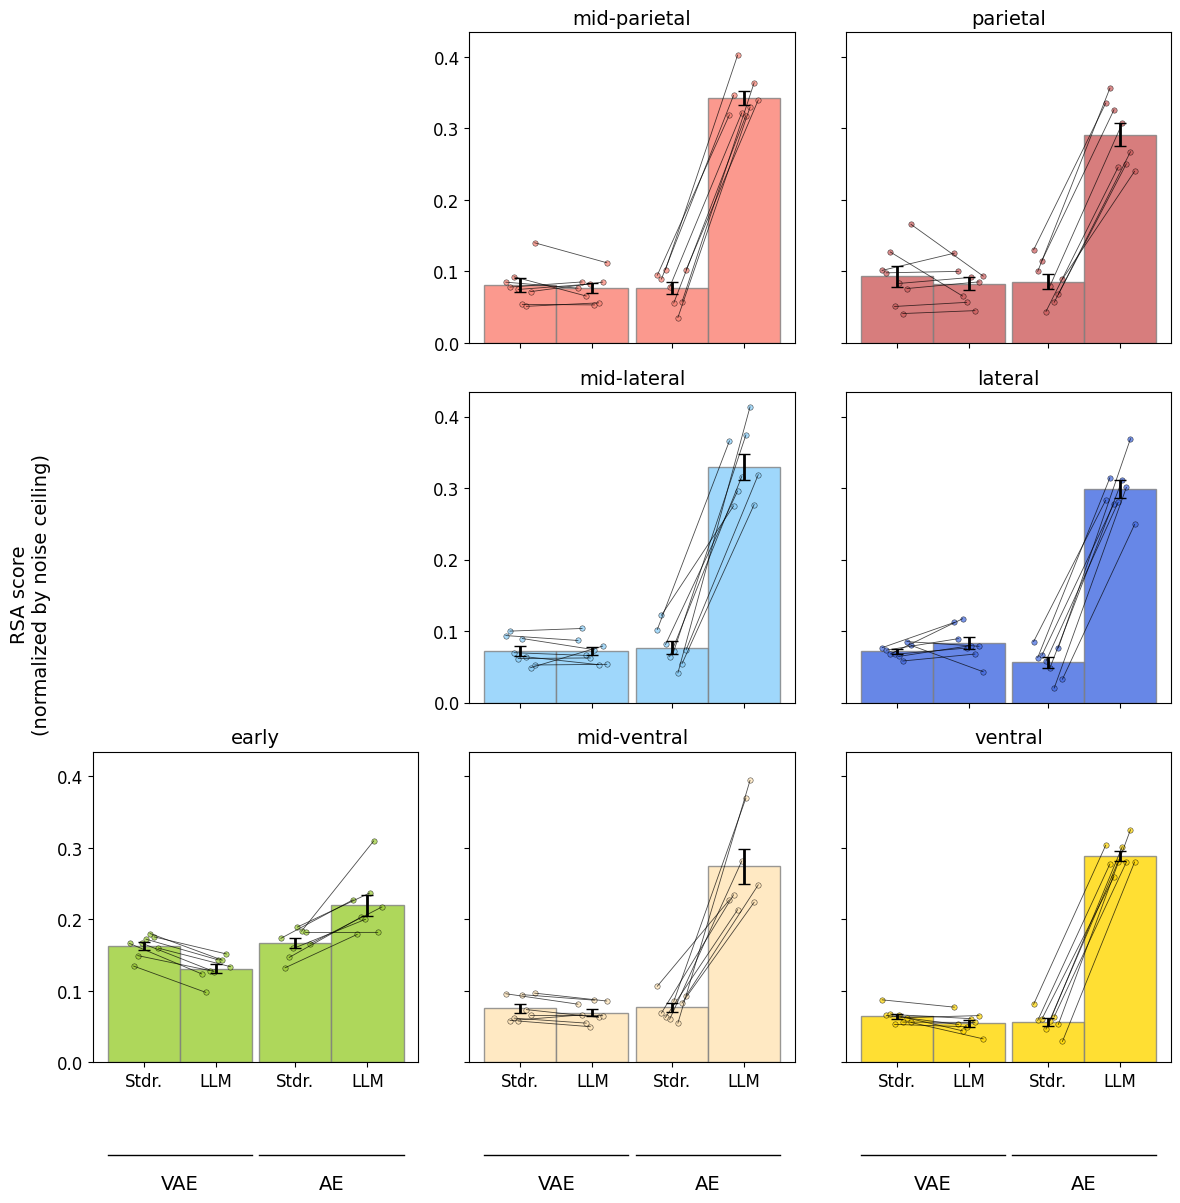

In [5]:
# per-ROI vertical bars in a 2D grid (axes swapped, grid transposed; participant-wise NC corrected)
target_layer = "all"
all_data = {}
for model_name, path_template in dict_models.items():
    rsa_data_path = path_template.format(layer=target_layer)
    with open(rsa_data_path, "r") as f:
        all_data[model_name] = json.load(f)

model_names = list(dict_models.keys())
# architecture name is shown as a group header below, so tick labels carry only the variant
model_labels = ["Stdr." if "Standard" in m else "LLM" for m in model_names]
n_models = len(model_names)
n_participants = 8
fontsize = 14
bar_w = 1
group_gap = 0.1

# connect subject dots only within the VAE pair and within the AE pair (standard <-> llm-guided),
# not across the VAE/AE boundary
connect_groups = [
    [k for k, m in enumerate(model_names) if "VAE" in m],
    [k for k, m in enumerate(model_names) if "VAE" not in m and "AE" in m],
]
# group headers (architecture) drawn under each pair
group_headers = ["VAE", "AE"]

# x positions: contiguous within a group, with a gap between VAE and AE groups
x_models = np.zeros(n_models)
x = 0.0
for gi, grp in enumerate(connect_groups):
    if gi > 0:
        x += group_gap
    for k in grp:
        x_models[k] = x
        x += 1.0

jitter = np.linspace(-bar_w * 0.2, bar_w * 0.2, num=n_participants)

# grid transposed (row <-> column)
roi_grid = [
    [None,    "midparietal", "parietal"],
    [None,    "midlateral",  "lateral"],
    ["early", "midventral",  "ventral"],
]
n_rows = len(roi_grid)
n_cols = max(len(r) for r in roi_grid)

# edge cells for tick labels (staircase-safe)
leftmost_col = {}
for r in range(n_rows):
    for c in range(n_cols):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            leftmost_col[r] = c
            break
bottom_row = {}
for c in range(n_cols):
    for r in range(n_rows):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            bottom_row[c] = r  # last non-None row in this column
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for r in range(n_rows):
    for c in range(n_cols):
        ax = axes[r, c]
        roi = roi_grid[r][c] if c < len(roi_grid[r]) else None
        if roi is None:
            ax.set_visible(False)
            continue

        nc = np.asarray(noise_ceiling[roi])
        color = pf.ROI_BASE_COLOR[roi]
        subject_points = {}

        for k, m in enumerate(model_names):
            vals = np.array(all_data[m][roi]) / nc  # participant-wise correction
            mean = np.mean(vals)
            sem = np.std(vals, ddof=1) / np.sqrt(len(vals))
            ax.bar(x_models[k], mean, width=bar_w,
                   color=color, alpha=0.8, edgecolor="grey", zorder=2,
                   yerr=sem, capsize=4,
                   error_kw={"zorder": 4, "linewidth": 2, "ecolor": "black"})
            for s, val in enumerate(vals):
                xpos = x_models[k] + jitter[s]
                ax.scatter(xpos, val, color=color, s=15, alpha=0.7,
                           edgecolors="black", linewidths=0.4, zorder=3)
                subject_points.setdefault(s, {})[k] = (xpos, val)

        for s, pts in subject_points.items():
            for grp in connect_groups:
                gp = [pts[k] for k in grp if k in pts]
                if len(gp) < 2:
                    continue
                ax.plot([p[0] for p in gp], [p[1] for p in gp],
                        color="black", linewidth=0.6, alpha=0.7, zorder=3)

        roi_label = roi.replace("mid", "mid-") if roi.startswith("mid") else roi
        ax.set_title(roi_label, fontsize=fontsize)

        # x tick labels (model variant) + architecture group header,
        # only on the bottom-most visible cell of each column
        if r == bottom_row.get(c):
            ax.set_xticks(x_models)
            ax.set_xticklabels(model_labels, rotation=0, ha="center", fontsize=fontsize - 2)
            ax.tick_params(axis="x", labelbottom=True)

            xtrans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
            for grp, header in zip(connect_groups, group_headers):
                x0 = x_models[grp[0]] - bar_w * 0.5
                x1 = x_models[grp[-1]] + bar_w * 0.5
                xc = 0.5 * (x0 + x1)
                # bracket line under the pair
                ax.plot([x0, x1], [-0.30, -0.30], transform=xtrans,
                        color="black", linewidth=1, clip_on=False)
                # architecture label below the bracket
                ax.text(xc, -0.36, header, transform=xtrans,
                        ha="center", va="top", fontsize=fontsize,
                        clip_on=False)
        else:
            ax.tick_params(axis="x", labelbottom=False)


        # y tick labels (score) only on the left-most visible cell of each row
        ax.tick_params(axis="y", labelleft=(c == leftmost_col.get(r)),
                       labelsize=fontsize - 2)
        ax.locator_params(axis="y", nbins=5)


fig.supylabel("RSA score\n(normalized by noise ceiling)", fontsize=fontsize, ma="center")

plt.tight_layout()
plt.show()

### latent variables

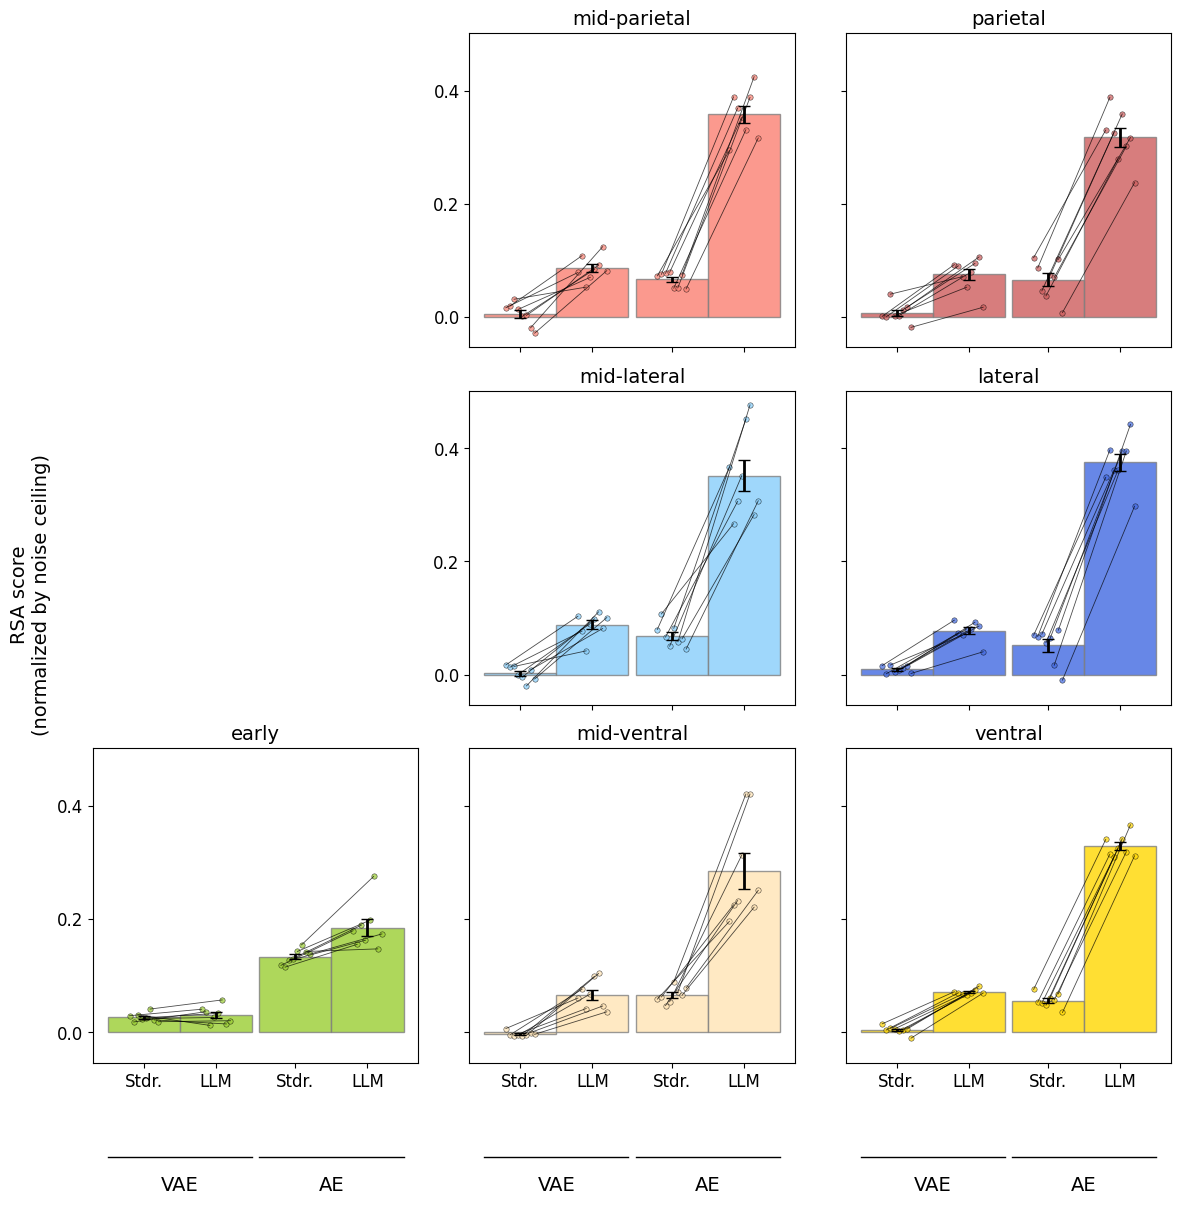

In [7]:
# per-ROI vertical bars in a 2D grid (axes swapped, grid transposed; participant-wise NC corrected)
target_layer = "latent"
all_data = {}
for model_name, path_template in dict_models.items():
    rsa_data_path = path_template.format(layer=target_layer)
    with open(rsa_data_path, "r") as f:
        all_data[model_name] = json.load(f)

model_names = list(dict_models.keys())
# architecture name is shown as a group header below, so tick labels carry only the variant
model_labels = ["Stdr." if "Standard" in m else "LLM" for m in model_names]
n_models = len(model_names)
n_participants = 8
fontsize = 14
bar_w = 1
group_gap = 0.1

# connect subject dots only within the VAE pair and within the AE pair (standard <-> llm-guided),
# not across the VAE/AE boundary
connect_groups = [
    [k for k, m in enumerate(model_names) if "VAE" in m],
    [k for k, m in enumerate(model_names) if "VAE" not in m and "AE" in m],
]
# group headers (architecture) drawn under each pair
group_headers = ["VAE", "AE"]

# x positions: contiguous within a group, with a gap between VAE and AE groups
x_models = np.zeros(n_models)
x = 0.0
for gi, grp in enumerate(connect_groups):
    if gi > 0:
        x += group_gap
    for k in grp:
        x_models[k] = x
        x += 1.0

jitter = np.linspace(-bar_w * 0.2, bar_w * 0.2, num=n_participants)

# grid transposed (row <-> column)
roi_grid = [
    [None,    "midparietal", "parietal"],
    [None,    "midlateral",  "lateral"],
    ["early", "midventral",  "ventral"],
]
n_rows = len(roi_grid)
n_cols = max(len(r) for r in roi_grid)

# edge cells for tick labels (staircase-safe)
leftmost_col = {}
for r in range(n_rows):
    for c in range(n_cols):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            leftmost_col[r] = c
            break
bottom_row = {}
for c in range(n_cols):
    for r in range(n_rows):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            bottom_row[c] = r  # last non-None row in this column
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for r in range(n_rows):
    for c in range(n_cols):
        ax = axes[r, c]
        roi = roi_grid[r][c] if c < len(roi_grid[r]) else None
        if roi is None:
            ax.set_visible(False)
            continue

        nc = np.asarray(noise_ceiling[roi])
        color = pf.ROI_BASE_COLOR[roi]
        subject_points = {}

        for k, m in enumerate(model_names):
            vals = np.array(all_data[m][roi]) / nc  # participant-wise correction
            mean = np.mean(vals)
            sem = np.std(vals, ddof=1) / np.sqrt(len(vals))
            ax.bar(x_models[k], mean, width=bar_w,
                   color=color, alpha=0.8, edgecolor="grey", zorder=2,
                   yerr=sem, capsize=4,
                   error_kw={"zorder": 4, "linewidth": 2, "ecolor": "black"})
            for s, val in enumerate(vals):
                xpos = x_models[k] + jitter[s]
                ax.scatter(xpos, val, color=color, s=15, alpha=0.7,
                           edgecolors="black", linewidths=0.4, zorder=3)
                subject_points.setdefault(s, {})[k] = (xpos, val)

        for s, pts in subject_points.items():
            for grp in connect_groups:
                gp = [pts[k] for k in grp if k in pts]
                if len(gp) < 2:
                    continue
                ax.plot([p[0] for p in gp], [p[1] for p in gp],
                        color="black", linewidth=0.6, alpha=0.7, zorder=3)

        roi_label = roi.replace("mid", "mid-") if roi.startswith("mid") else roi
        ax.set_title(roi_label, fontsize=fontsize)

        # x tick labels (model variant) + architecture group header,
        # only on the bottom-most visible cell of each column
        if r == bottom_row.get(c):
            ax.set_xticks(x_models)
            ax.set_xticklabels(model_labels, rotation=0, ha="center", fontsize=fontsize - 2)
            ax.tick_params(axis="x", labelbottom=True)

            xtrans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
            for grp, header in zip(connect_groups, group_headers):
                x0 = x_models[grp[0]] - bar_w * 0.5
                x1 = x_models[grp[-1]] + bar_w * 0.5
                xc = 0.5 * (x0 + x1)
                # bracket line under the pair
                ax.plot([x0, x1], [-0.30, -0.30], transform=xtrans,
                        color="black", linewidth=1, clip_on=False)
                # architecture label below the bracket
                ax.text(xc, -0.36, header, transform=xtrans,
                        ha="center", va="top", fontsize=fontsize,
                        clip_on=False)
        else:
            ax.tick_params(axis="x", labelbottom=False)


        # y tick labels (score) only on the left-most visible cell of each row
        ax.tick_params(axis="y", labelleft=(c == leftmost_col.get(r)),
                       labelsize=fontsize - 2)
        ax.locator_params(axis="y", nbins=5)


fig.supylabel("RSA score\n(normalized by noise ceiling)", fontsize=fontsize, ma="center")

plt.tight_layout()
plt.show()

# Encoder vs Decoder

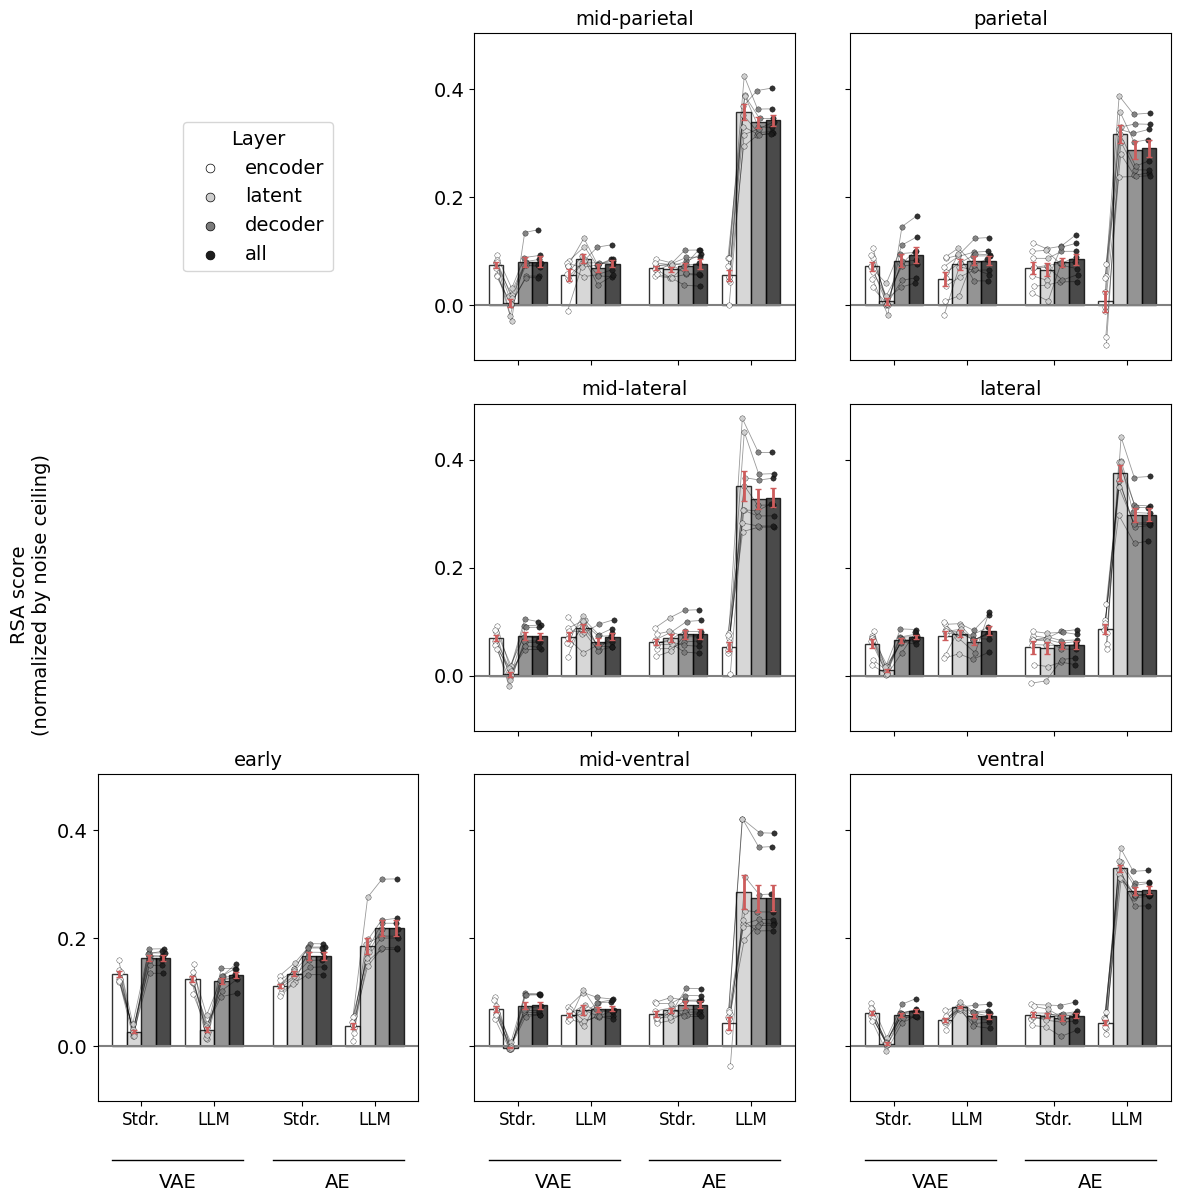

In [6]:
# plot rsa results - layers color-coded, models on x-axis, arranged in a roi_grid (staircase)
# xlabels: short variant ticks (Stdr./LLM) + VAE/AE group brackets, edge cells only
fontsize = 14

# load everything first: full_data[model_name][layer][roi] = list of subject values
full_data = {}
for model_name, path_template in dict_models.items():
    full_data[model_name] = {}
    for layer in list_layers:
        rsa_data_path = path_template.format(layer=layer)
        with open(rsa_data_path, "r") as f:
            full_data[model_name][layer] = json.load(f)

model_names = list(dict_models.keys())
# architecture name is shown as a group header below, so tick labels carry only the variant
model_labels = ["Stdr." if "Standard" in m else "LLM" for m in model_names]
n_models = len(model_names)
n_layers = len(list_layers)
colors = plt.cm.Greys(np.linspace(0, 0.9, n_layers))

bar_w_group = 0.8         # total width occupied by the layer-bars of one model
width = bar_w_group / n_layers
group_gap = 0.2            # gap between the VAE pair and the AE pair

# connect subject dots only within the VAE pair and within the AE pair (for the bracket headers)
connect_groups = [
    [k for k, m in enumerate(model_names) if "VAE" in m],
    [k for k, m in enumerate(model_names) if "VAE" not in m and "AE" in m],
]
group_headers = ["VAE", "AE"]

# x positions: contiguous within a group, with a gap between VAE and AE groups
x_models = np.zeros(n_models)
x = 0.0
for gi, grp in enumerate(connect_groups):
    if gi > 0:
        x += group_gap
    for k in grp:
        x_models[k] = x
        x += 1.0

# grid (transposed staircase); "all" excluded
n_rows = len(roi_grid)
n_cols = max(len(r) for r in roi_grid)

# edge cells for tick labels (staircase-safe)
leftmost_col = {}
for r in range(n_rows):
    for c in range(n_cols):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            leftmost_col[r] = c
            break
bottom_row = {}
for c in range(n_cols):
    for r in range(n_rows):
        if c < len(roi_grid[r]) and roi_grid[r][c] is not None:
            bottom_row[c] = r  # last non-None row in this column

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for r in range(n_rows):
    for c in range(n_cols):
        ax = axes[r, c]
        roi = roi_grid[r][c] if c < len(roi_grid[r]) else None
        if roi is None:
            ax.set_visible(False)
            continue

        nc = np.asarray(noise_ceiling[roi])
        subject_points = {}  # subject_points[s][model_name] = list of (x_pos, y_val) across layers

        for i, (layer, color) in enumerate(zip(list_layers, colors)):
            offset = (i - n_layers / 2 + 0.5) * width
            positions = x_models + offset

            for j, model_name in enumerate(model_names):
                this_data = np.array(full_data[model_name][layer][roi]) / nc  # participant-wise
                jitter = np.random.uniform(-width * 0.1, width * 0.1, size=len(this_data))

                for s, (val, jit) in enumerate(zip(this_data, jitter)):
                    xpos = positions[j] + jit
                    ax.scatter(xpos, val, color=color, s=15, zorder=3, alpha=0.9,
                               edgecolors='black', linewidths=0.25)
                    subject_points.setdefault(s, {}).setdefault(model_name, []).append((xpos, val))

                # mean bar
                mean = np.mean(this_data)
                sem = np.std(this_data, ddof=1) / np.sqrt(len(this_data))
                ax.bar(positions[j], np.mean(this_data), width,
                       facecolor=color, alpha=0.8, zorder=2, edgecolor='black',
                       yerr=sem, capsize=2,
                       error_kw={"zorder": 4, "linewidth": 2, "ecolor": "indianred"})

        # subject lines connect a participant's points across layers, within each model
        for s, model_dict in subject_points.items():
            for model_name, points in model_dict.items():
                ax.plot([p[0] for p in points], [p[1] for p in points],
                        color='black', linewidth=0.6, alpha=0.4, zorder=2)

        roi_label = roi.replace("mid", "mid-") if roi.startswith("mid") else roi
        ax.set_title(roi_label, fontsize=fontsize)
        #ax.set_ylim(bottom=0)
        ax.axhline(y=0, color='grey',linestyle='-')

        # x tick labels (model variant) + architecture group header,
        # only on the bottom-most visible cell of each column
        if r == bottom_row.get(c):
            ax.set_xticks(x_models)
            ax.set_xticklabels(model_labels, rotation=0, ha="center", fontsize=fontsize - 2)
            ax.tick_params(axis="x", labelbottom=True)

            xtrans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
            for grp, header in zip(connect_groups, group_headers):
                x0 = x_models[grp[0]] - bar_w_group * 0.5
                x1 = x_models[grp[-1]] + bar_w_group * 0.5
                xc = 0.5 * (x0 + x1)
                ax.plot([x0, x1], [-0.18, -0.18], transform=xtrans,
                        color="black", linewidth=1, clip_on=False)
                ax.text(xc, -0.22, header, transform=xtrans,
                        ha="center", va="top", fontsize=fontsize, clip_on=False)
        else:
            ax.tick_params(axis="x", labelbottom=False)

        # y tick labels only on the left-most visible cell of each row
        ax.tick_params(axis="y", labelleft=(c == leftmost_col.get(r)), labelsize=fontsize)
        ax.locator_params(axis="y", nbins=5)

fig.supylabel("RSA score\n(normalized by noise ceiling)", fontsize=fontsize, ma="center")

# shared legend (layers) in the empty top-left cell (roi_grid[0][0] is None)
handles = [plt.scatter([], [], color=color, s=40, edgecolors='black', linewidths=0.5, label=layer)
           for layer, color in zip(list_layers, colors)]
ax_legend = axes[0, 0]
ax_legend.set_visible(True)
ax_legend.axis("off")
ax_legend.legend(handles=handles, title='Layer', loc='center',
                 fontsize=fontsize, title_fontsize=fontsize)


plt.tight_layout()
plt.show()
